<a href="https://colab.research.google.com/github/charlesembo99/charlesembo99/blob/master/cs_da02_25013_RegressionAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To upload files from your local machine to this Colab environment, you can use `google.colab.files.upload()`. This function will open a file selection dialog in your browser, allowing you to choose one or more files to upload.

In [ ]:
#uploading the required data from my local machine
from google.colab import files

try:
  uploaded = files.upload()
  for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
except Exception as e:
  print(f"An error occurred: {e}")

Saving areas.csv to areas.csv
Saving homeprices.csv to homeprices (1).csv
Saving homeprices-m.csv to homeprices-m.csv
User uploaded file "areas.csv" with length 70 bytes
User uploaded file "homeprices (1).csv" with length 71 bytes
User uploaded file "homeprices-m.csv" with length 123 bytes


In [ ]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#loading the data ,Exploring the data
areas = pd.read_csv('areas.csv')
homeprices = pd.read_csv('homeprices.csv')
homeprices_m = pd.read_csv('homeprices-m.csv')
print('----------------------------------')
#first 5 rows of each data
print(f'areas:{areas.head()}')
print(f'homeprices:{homeprices.head()}')
print(f'homeprices_m:{homeprices_m.head()}')
print('----------------------------------')

# Exploring more information about our data frame
print(f'areas info:{areas.info()}')
print(f'homeprices info:{homeprices.info()}')
print(f'homeprices_m info:{homeprices_m.info()}')
print('----------------------------------')

#Explorating the shape of the data
print(f'areas shape:{areas.shape}')
print(f'homeprices shape:{homeprices.shape}')
print(f'homeprices_m shape:{homeprices_m.shape}')
print(f'missing values in homeprices:{homeprices.isnull().sum()}')
print(f'missing values in areas:{areas.isnull().sum()}')
print(f'missing values in homeprices_m:{homeprices_m.isnull().sum()}')
print('----------------------------------')

#Describing the structure of the colums in our data
print(f'areas info:{areas.describe()}')
print(f'homeprices info:{homeprices.describe()}')

print('----------------------------------')



----------------------------------
areas:   area
0  1000
1  1500
2  2300
3  3540
4  4120
homeprices:   area   price
0  2600  550000
1  3000  565000
2  3200  610000
3  3600  680000
4  4000  725000
homeprices_m:   area  bedrooms  age   price
0  2600       3.0   20  550000
1  3000       4.0   15  565000
2  3200       NaN   18  610000
3  3600       3.0   30  595000
4  4000       5.0    8  760000
----------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    13 non-null     int64
dtypes: int64(1)
memory usage: 236.0 bytes
areas info:None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    5 non-null      int64
 1   price   5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes
homeprices info:None


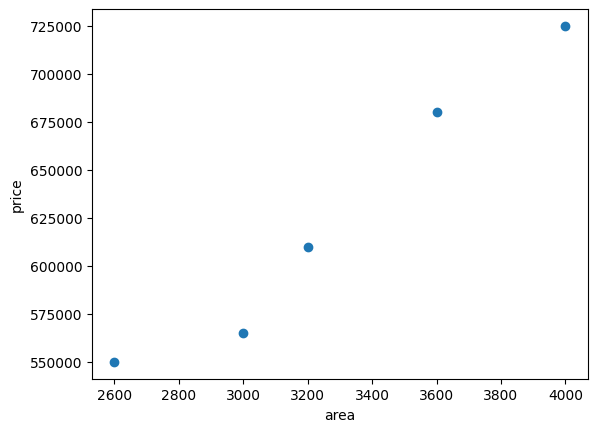

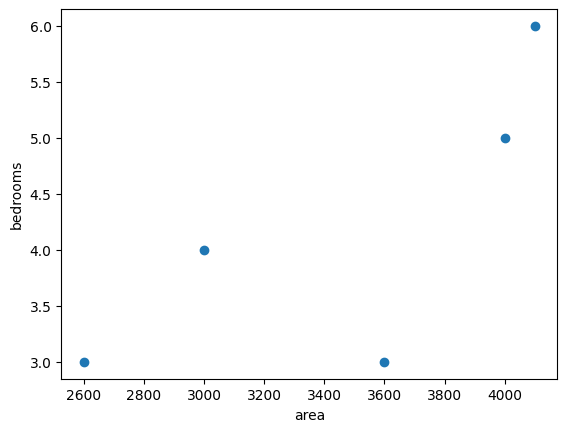

In [ ]:
#scatter plot of area vs prices and area vs bedrooms
plt.scatter(homeprices['area'],homeprices['price'])
plt.xlabel('area')
plt.ylabel('price')
plt.show()
#scatter plot for areas and bedrooms
plt.scatter(homeprices_m['area'],homeprices_m['bedrooms'])
plt.xlabel('area')
plt.ylabel('bedrooms')
plt.show()


In [ ]:
#Handling missing values
bedroom_mean = homeprices_m['bedrooms'].mean()
homeprices_m['bedrooms'] = homeprices_m['bedrooms'].fillna(bedroom_mean)
#confirming if the missing values has been handled
print(f'missing values in homeprices_m:{homeprices_m.isnull().sum()}')

missing values in homeprices_m:area        0
bedrooms    0
age         0
price       0
dtype: int64


In [ ]:
# Create a linear regression object
reg = linear_model.LinearRegression()
# Train the model using the homeprices dataset
reg.fit(homeprices[['area']], homeprices['price'])

LinearRegression()

In [ ]:
print(f'Coefficient (slope): {reg.coef_[0]}')
print(f'Intercept: {reg.intercept_}')

Coefficient (slope): 135.78767123287673
Intercept: 180616.43835616432


In [ ]:
predicted_price = reg.predict([[3300]])
print(f'Predicted price for a 3300 sq ft house: {predicted_price[0]:.2f}')

Predicted price for a 3300 sq ft house: 628715.75


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


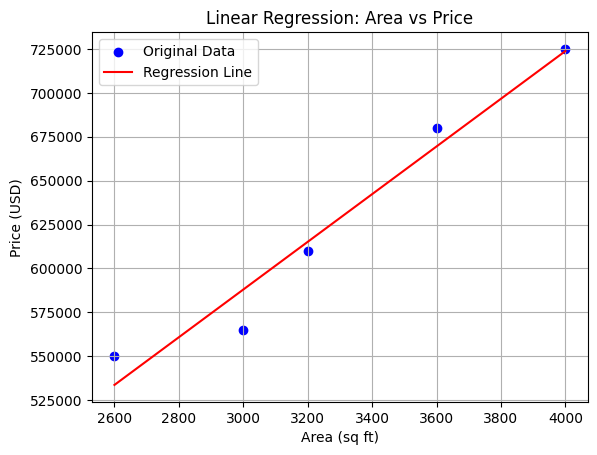

In [ ]:
plt.scatter(homeprices['area'], homeprices['price'], color='blue', label='Original Data')
plt.plot(homeprices['area'], reg.predict(homeprices[['area']]), color='red', label='Regression Line')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price (USD)')
plt.title('Linear Regression: Area vs Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Get predictions on the training data
y_predicted = reg.predict(homeprices[['area']])

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(homeprices['price'], y_predicted)

# Calculate R-squared (R2) score
r2 = r2_score(homeprices['price'], y_predicted)

print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R-squared (R2) Score: {r2:.2f}')

Mean Squared Error (MSE): 186815068.49
R-squared (R2) Score: 0.96
